In [1]:
# Import libraries
import pandas as pd
import numpy as np
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
# Load dataset
data = pd.read_csv(r"D:\letter-recognition.data", header=None)

In [5]:
# Features and labels
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

In [7]:
# Convert letters A-Z into numbers 0-25
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [9]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
# Build DNN model
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(26, activation='softmax')   # 26 classes
])

In [18]:
# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.5974 - loss: 1.4804 - val_accuracy: 0.7575 - val_loss: 0.8446
Epoch 2/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7983 - loss: 0.6984 - val_accuracy: 0.8138 - val_loss: 0.6096
Epoch 3/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8485 - loss: 0.5246 - val_accuracy: 0.8619 - val_loss: 0.4716
Epoch 4/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8785 - loss: 0.4205 - val_accuracy: 0.8756 - val_loss: 0.4100
Epoch 5/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8933 - loss: 0.3568 - val_accuracy: 0.8956 - val_loss: 0.3473
Epoch 6/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9081 - loss: 0.3065 - val_accuracy: 0.9044 - val_loss: 0.3139
Epoch 7/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9221 - loss: 0.2684 - val_accuracy: 0.9131 - val_loss: 0.2850
Epoch 8/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9276 - loss: 0.2382 - val_accuracy: 0

In [23]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9597 - loss: 0.1493   


In [25]:
print("Accuracy:", accuracy)

Accuracy: 0.9597499966621399


In [27]:
# Predictions
predictions = model.predict(X_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [29]:
# Convert probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)

In [31]:
# Display sample predictions
for i in range(10):
    actual = encoder.inverse_transform([y_test[i]])[0]
    predicted = encoder.inverse_transform([predicted_classes[i]])[0]

    print(f"Actual: {actual} | Predicted: {predicted}")


Actual: T | Predicted: Z
Actual: L | Predicted: L
Actual: A | Predicted: A
Actual: E | Predicted: E
Actual: Q | Predicted: Q
Actual: E | Predicted: E
Actual: O | Predicted: O
Actual: Q | Predicted: Q
Actual: G | Predicted: G
Actual: O | Predicted: O


In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,368 (142.07 KB)

 Trainable params: 12,122 (47.35 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,246 (94.71 KB)

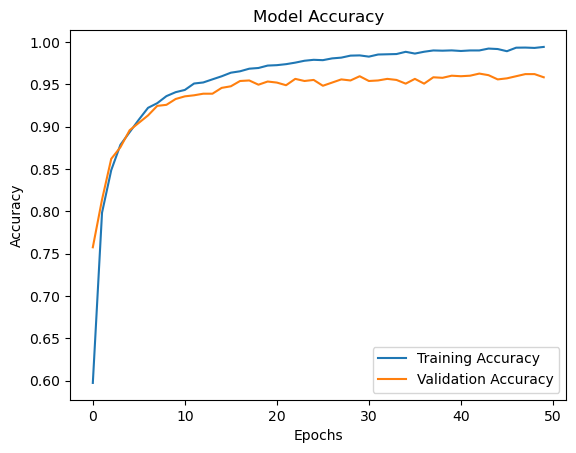

In [35]:
# Plot accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.show()